# TS5: Estimación espectral: Ancho de banda de señales reales

## Alumnos: Felipe Berganza, Facundo Carranza

## Resumen 

Este proyecto aborda el análisis espectral de señales biomédicas (ECG y PPG) y audios mediante técnicas de estimación de densidad espectral de potencia (PSD), con el objetivo de caracterizar su contenido frecuencial y determinar frecuencias de corte relevantes. Cual obejetivo es comparar el contenido espectral de señales limpias vs. ruidosas, identificar frecuencias relevantes, y aplicar técnicas robustas de estimación espectral para caracterización y filtrado.
Abordando la utilizacion de los siguientes metodos: 
1. Métodos de Estimación Espectral
- Welch: Se aplica con ventana flattop y promediado segmentado para mejorar la estimación espectral.
- Blackman-Tukey: Se implementa como función personalizada, usando autocorrelación truncada y ventana Hann.
- Periodograma Ventaneado: Se usa en señales de audio con ventana Blackman y escala en decibeles.





## INTRODUCCION 

## Densidad Espectral de Potencia (PSD)

La Densidad Espectral de Potencia (PSD) es una herramienta fundamental en el análisis de señales, especialmente en contextos donde se busca caracterizar el contenido frecuencial de fenómenos físicos, biomédicos o acústicos. A diferencia del espectro de Fourier, que representa la amplitud de componentes senoidales, la PSD describe cómo se distribuye la potencia de una señal a lo largo del eje de frecuencias.
Desde una perspectiva matemática, la PSD se define como el límite de la energía promedio por unidad de frecuencia, y permite identificar qué bandas contienen mayor energía, facilitando tareas como el diseño de filtros, la detección de ruido o la extracción de patrones fisiológicos.
En señales aleatorias o no determinísticas, como las biomédicas (ECG, PPG), la PSD ofrece una estimación robusta del comportamiento espectral, incluso en presencia de ruido. Métodos como el periodograma, Welch, o Blackman-Tukey permiten obtener estimaciones de la PSD con diferentes compromisos entre resolución, sesgo y varianza.
El análisis espectral mediante PSD no solo revela la estructura interna de las señales, sino que también permite cuantificar la energía acumulada, establecer frecuencias de corte y comparar el impacto del ruido sobre la señal original.

## Metodos Espectrales

- Welch: La idea central del método consiste en dividir la señal en segmentos superpuestos, aplicar una ventana a cada uno de ellos (como Hamming, Hann o Flattop), calcular el periodograma de cada segmento, y luego promediar los resultados. Este enfoque permite suavizar las fluctuaciones espectrales causadas por la finitud de los datos y por la presencia de ruido.

- Blackman-Tukey: La lógica detrás del método es que la PSD de una señal puede obtenerse como la transformada de Fourier de su autocorrelación. Sin embargo, como en la práctica solo se dispone de una cantidad finita de datos, se utiliza una versión truncada de la autocorrelación, suavizada mediante una ventana (por ejemplo, Hann, Blackman, Bartlett) para reducir el efecto de discontinuidades y minimizar el efecto de fuga espectral.

- Periodograma Ventaneo: Se basa en aplicar la transformada rápida de Fourier (FFT) a la señal, pero con una mejora clave: antes de transformarla, se multiplica por una ventana de suavizado que atenúa los extremos del segmento temporal. Tiene como objetivo reducir el efecto de fuga espectral (spectral leakage), que ocurre cuando la señal no es perfectamente periódica dentro del intervalo analizado. Al suavizar los bordes, se minimizan las discontinuidades que generan energía espuria en frecuencias no presentes originalmente.




## DESARROLLO DE CODIGO

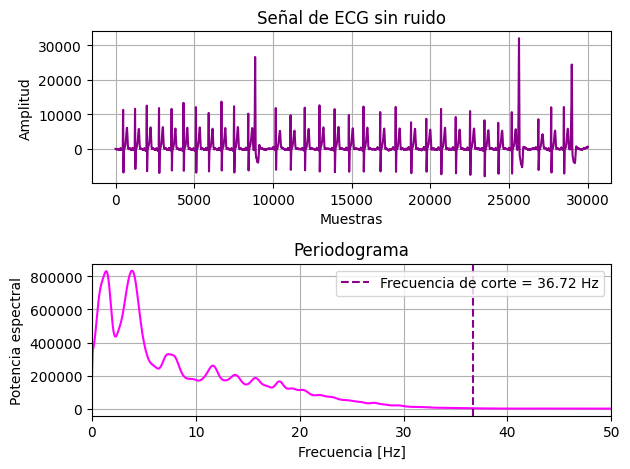

In [4]:
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt
from numpy.fft import fft
import scipy.signal.windows as window
import scipy.io as sio


# ------------------------------------------- Blackman-Tukey ------------------------------------------- #


def blackman_tukey (x, M):
    
    N = len(x)
    x_shape = x.shape
    
    if M == None:
        M = N//5
    
    len_r = (2*M)-1
    xx = x.ravel()[:len_r]
    
    r_xx = np.correlate (xx, xx, mode='same') / len_r
    
    per_BT = np.abs (fft(r_xx * window.hann(len_r), n=N))
    per_BT = per_BT.reshape(x_shape)
    
    return per_BT

# ------------------------------------------- Lecutra de ECG ------------------------------------------- #


fs_ECG = 1000

mat_struct = sio.loadmat ('./ECG_TP4.mat')

ecg_one_lead = mat_struct ['ecg_lead'] 

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']


# ------------------------------------------- ECG sin ruido ------------------------------------------- #


ECG_sr = np.load ('ecg_sin_ruido.npy')

N_ECG_sr = len (ECG_sr)

df_ECG_sr = fs_ECG / N_ECG_sr
nn_ECG_sr = np.arange (N_ECG_sr)

promedios_ECG_sr = 12 
nperseg_ECG_sr = N_ECG_sr // promedios_ECG_sr
ff_ECG_sr, per_ECG_sr = sp.welch (ECG_sr, nfft = 5*nperseg_ECG_sr, fs = fs_ECG, nperseg = nperseg_ECG_sr, window = 'flattop') # N/nperseg es la cantidad de promedios que quiero hacer

energia_acum_sr = np.cumsum (per_ECG_sr) 
energia_acum_sr_norm = energia_acum_sr / energia_acum_sr[-1] 
corte_ECG_sr = energia_acum_sr_norm[-1] * 0.995
indice_corte_sr = int (np.where (energia_acum_sr_norm >= corte_ECG_sr)[0][0])
frec_corte_sr = ff_ECG_sr[indice_corte_sr]


plt.figure (2)

plt.subplot (2, 1, 1)
plt.plot (nn_ECG_sr, ECG_sr, color='darkmagenta')
plt.title ("Señal de ECG sin ruido")
plt.ylabel ("Amplitud")
plt.xlabel ("Muestras")
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_ECG_sr, per_ECG_sr, color='magenta')
plt.axvline (frec_corte_sr, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_sr:.2f} Hz')
plt.title ("Periodograma")
plt.ylabel("Potencia espectral")
plt.xlabel ("Frecuencia [Hz]")
plt.grid (True)
plt.legend ()
plt.xlim (0, 50)

plt.tight_layout()
plt.show()

## Interpretación

- La señal sin ruido presenta un espectro concentrado en bajas frecuencias (típicamente < 40 Hz).
- La frecuencia de corte calculada permite cuantificar el ancho de banda útil.
- El uso de Welch con ventana flattop mejora la estabilidad de la estimación sin perder fidelidad en amplitudes.




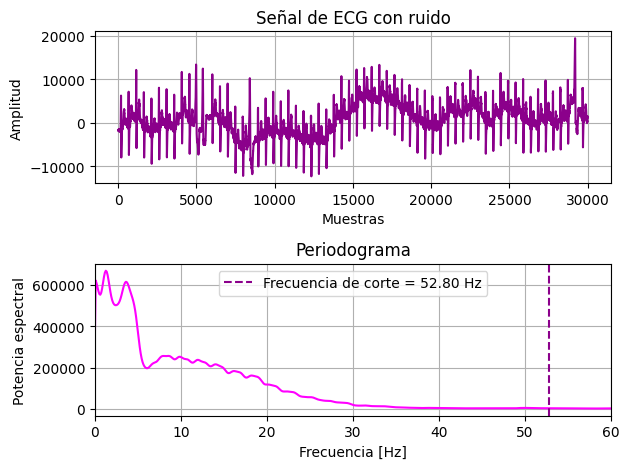

In [5]:
# ------------------------------------------- ECG con ruido ------------------------------------------- #


ECG_cr = ecg_one_lead[670000:700000].ravel()

N_ECG_cr = len (ECG_cr)

df_ECG_cr = fs_ECG / N_ECG_cr
nn_ECG_cr = np.arange (N_ECG_cr)

promedios_ECG_cr = 16
nperseg_ECG_cr = N_ECG_cr // promedios_ECG_cr

ff_ECG_cr, per_ECG_cr = sp.welch (ECG_cr, nfft = 5*nperseg_ECG_cr, fs = fs_ECG, nperseg = nperseg_ECG_cr, window = 'flattop')

energia_acum_cr = np.cumsum (per_ECG_cr)
energia_acum_cr_norm = energia_acum_cr / energia_acum_cr[-1]
corte_ECG_cr = energia_acum_cr_norm[-1] * 0.995
indice_corte_cr = int (np.where (energia_acum_cr_norm >= corte_ECG_cr)[0][0])
frec_corte_cr = ff_ECG_cr[indice_corte_cr]


plt.figure (3)

plt.subplot (2, 1, 1)
plt.plot (nn_ECG_cr, ECG_cr, color='darkmagenta')
plt.title ("Señal de ECG con ruido")
plt.ylabel ("Amplitud")
plt.xlabel ("Muestras")
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_ECG_cr, per_ECG_cr, color='magenta')
plt.axvline (frec_corte_cr, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_cr:.2f} Hz')
plt.title ("Periodograma")
plt.ylabel("Potencia espectral")
plt.xlabel ("Frecuencia [Hz]")
plt.grid (True)
plt.legend ()
plt.xlim (0, 60)

plt.tight_layout()
plt.show()

## Interpretación
- La señal presenta mayor dispersión espectral que la versión sin ruido.
- El contenido energético se extiende hacia frecuencias más altas, lo que indica la presencia de componentes no fisiológicos.
- La frecuencia de corte es mayor que en la señal limpia, reflejando el impacto del ruido en el espectro.


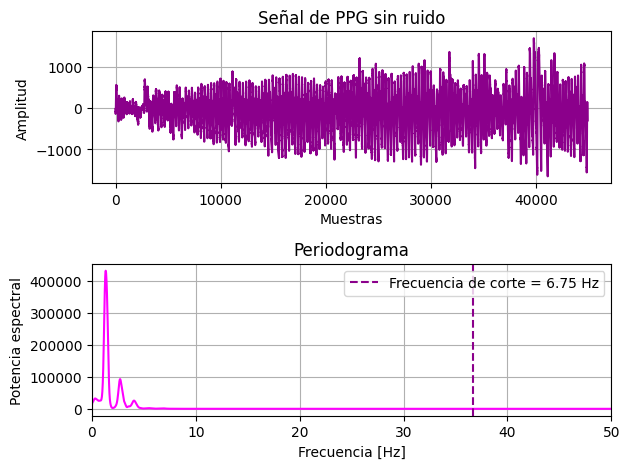

In [6]:
# ------------------------------------------- PPG sin ruido ------------------------------------------- #

fs_PPG = 400

PPG_sr = np.load('ppg_sin_ruido.npy')

N_PPG_sr = len (PPG_sr)

df_PPG_sr = fs_PPG / N_PPG_sr
nn_PPG_sr = np.arange (N_PPG_sr)

promedios_PPG_sr = 12
nperseg_PPG_sr = N_PPG_sr // promedios_PPG_sr

ff_PPG_sr, per_PPG_sr = sp.welch (PPG_sr, nfft = 5*nperseg_PPG_sr, fs = fs_PPG, nperseg = nperseg_PPG_sr, window = 'flattop')

energia_acum_PPG_sr = np.cumsum (per_PPG_sr)
energia_acum_PPG_sr_norm = energia_acum_PPG_sr / energia_acum_PPG_sr[-1]
corte_PPG_sr = energia_acum_PPG_sr_norm[-1] * 0.995
indice_corte_PPG_sr = int (np.where (energia_acum_PPG_sr_norm >= corte_PPG_sr)[0][0])
frec_corte_PPG_sr = ff_PPG_sr[indice_corte_PPG_sr]

plt.figure (4)

plt.subplot (2, 1, 1)
plt.plot (nn_PPG_sr, PPG_sr, color='darkmagenta')
plt.title ("Señal de PPG sin ruido")
plt.ylabel ("Amplitud")
plt.xlabel ("Muestras")
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_PPG_sr, per_PPG_sr, color='magenta')
plt.axvline (frec_corte_sr, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_PPG_sr:.2f} Hz')
plt.title ("Periodograma")
plt.ylabel("Potencia espectral")
plt.xlabel ("Frecuencia [Hz]")
plt.grid (True)
plt.legend ()
plt.xlim (0, 50)

plt.tight_layout()
plt.show()


## Interpretación
- La señal PPG sin ruido presenta un espectro concentrado en bajas frecuencias,  entre 0.5 y 5 Hz.
- La frecuencia de corte calculada permite delimitar el ancho de banda útil para análisis fisiológico o diseño de filtros.
- El uso de Welch con ventana flattop proporciona una estimación estable y confiable del contenido espectral.


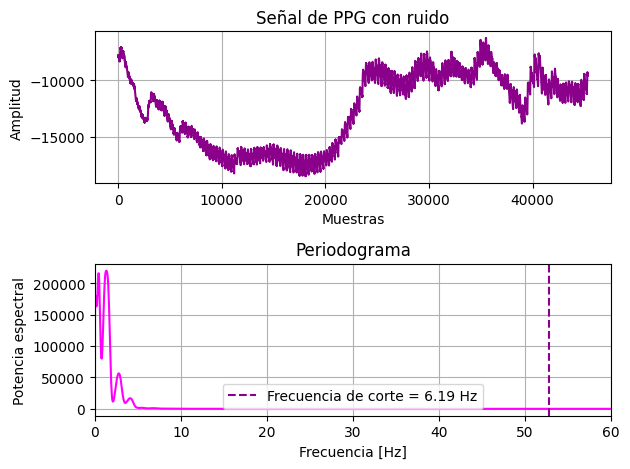

In [7]:
# ------------------------------------------- PPG con ruido ------------------------------------------- #


PPG_cr = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1) # omite la cabecera, si existe

N_PPG_cr = len (PPG_cr)

df_PPG_cr = fs_PPG / N_PPG_cr
nn_PPG_cr = np.arange (N_PPG_cr)

promedios_PPG_cr = 24
nperseg_PPG_cr = N_PPG_cr // promedios_PPG_cr

ff_PPG_cr, per_PPG_cr = sp.welch (PPG_cr, nfft = 5*nperseg_PPG_cr, fs = fs_PPG, nperseg = nperseg_PPG_cr, window = 'flattop')

energia_acum_PPG_cr = np.cumsum (per_PPG_cr)
energia_acum_PPG_cr_norm = energia_acum_PPG_cr / energia_acum_PPG_cr[-1]
corte_PPG_cr = energia_acum_PPG_cr_norm[-1] * 0.995
indice_corte_PPG_cr = int (np.where (energia_acum_PPG_cr_norm >= corte_PPG_cr)[0][0])
frec_corte_PPG_cr = ff_PPG_cr[indice_corte_PPG_cr]

plt.figure (5)

plt.subplot (2, 1, 1)
plt.plot (nn_PPG_cr, PPG_cr, color='darkmagenta')
plt.title ("Señal de PPG con ruido")
plt.ylabel ("Amplitud")
plt.xlabel ("Muestras")
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_PPG_cr, per_PPG_cr, color='magenta')
plt.axvline (frec_corte_cr, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_PPG_cr:.2f} Hz')
plt.title ("Periodograma")
plt.ylabel("Potencia espectral")
plt.xlabel ("Frecuencia [Hz]")
plt.grid (True)
plt.legend ()
plt.xlim (0, 60)

plt.tight_layout()
plt.show()

## Interpretación
- La señal presenta mayor dispersión espectral que la versión sin ruido.
- El contenido energético se extiende hacia frecuencias más altas, lo que indica la presencia de componentes no fisiológicos o artefactos.
- La frecuencia de corte es mayor que en la señal limpia, reflejando el impacto del ruido en el espectro.


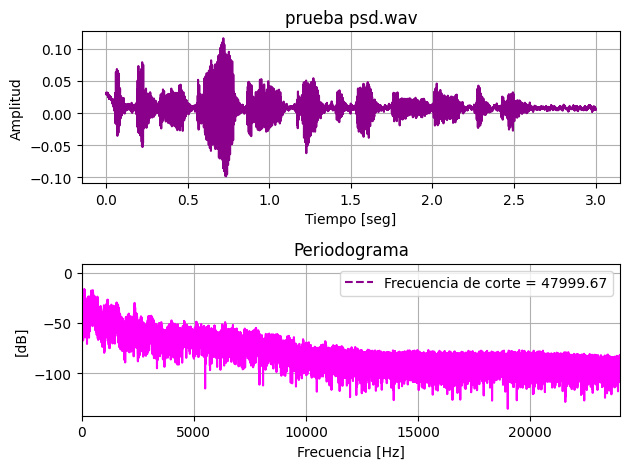

In [8]:
# ------------------------------------------- Lectura de audios ------------------------------------------- #


fs_1, wav_data_1 = sio.wavfile.read ('prueba psd.wav')
fs_2, wav_data_2 = sio.wavfile.read ('silbido.wav')
fs_3, wav_data_3 = sio.wavfile.read ('la cucaracha.wav')

N_1 = len(wav_data_1)
N_2 = len(wav_data_2)
N_3 = len(wav_data_3)

df_1 = fs_1 / N_1
df_2 = fs_2 / N_2
df_3 = fs_3 / N_3

tt_1 = np.arange (0, N_1/fs_1, 1/fs_1)
tt_2 = np.arange (0, N_2/fs_2, 1/fs_2)
tt_3 = np.arange (0, N_3/fs_3, 1/fs_3)

ff_1 = np.arange (N_1) * df_1
ff_2 = np.arange (N_2) * df_2
ff_3 = np.arange (N_3) * df_3


# ------------------------------------------- Audio 1 -> 'prueba psd.wav' ------------------------------------------- #


# Utilizo método del Periodograma Ventaneado
per_audio_1 = np.abs ((fft (wav_data_1 * window.blackman(N_1)))**2) / N_1
per_audio_1_dB = 10*np.log10(per_audio_1)

energia_acum_1 = np.cumsum (per_audio_1)
energia_acum_1_norm = energia_acum_1 / energia_acum_1[-1]
corte_1 = energia_acum_1_norm[-1] * 0.995
indice_corte_1 = (int) (np.where (energia_acum_1_norm >= corte_1)[0][0])
frec_corte_1 = ff_1[indice_corte_1]


plt.figure (6)

plt.subplot (2, 1, 1)
plt.plot (tt_1, wav_data_1, color='darkmagenta')
plt.title ('prueba psd.wav')
plt.xlabel ('Tiempo [seg]')
plt.ylabel ('Amplitud')
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_1, per_audio_1_dB, color='magenta')
plt.axvline (frec_corte_1, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_1:.2f}')
plt.title ('Periodograma')
plt.xlabel ('Frecuencia [Hz]')
plt.ylabel ('[dB]')
plt.xlim (0, fs_1/2)
plt.grid (True)
plt.legend ()

plt.tight_layout()
plt.show()


## Interpretación
- El espectro revela las componentes dominantes del audio, permitiendo identificar tonos, ruidos o patrones acústicos.
- La frecuencia de corte indica el rango útil del contenido espectral, útil para compresión, filtrado o clasificación.
- El uso de ventana Blackman mejora la resolución espectral y reduce artefactos.


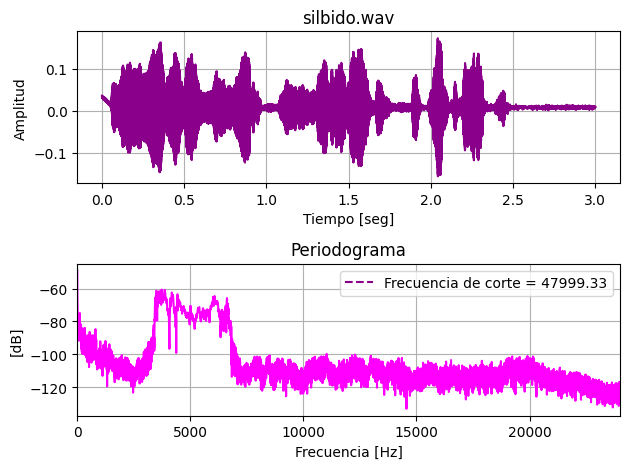

In [9]:
# ------------------------------------------- Audio 2 -> 'silbido.wav' ------------------------------------------- #


# Utilizo método de Blackman-Tukey
per_audio_2 = blackman_tukey (wav_data_2, M = None) / N_2
per_audio_2_dB = 10*np.log10(per_audio_2)

energia_acum_2 = np.cumsum (per_audio_2)
energia_acum_2_norm = energia_acum_2 / energia_acum_2[-1]
corte_2 = energia_acum_2_norm[-1] * 0.995
indice_corte_2 = (int) (np.where (energia_acum_2_norm >= corte_2)[0][0])
frec_corte_2 = ff_2[indice_corte_2]


plt.figure (7)

plt.subplot (2, 1, 1)
plt.plot (tt_2, wav_data_2, color='darkmagenta')
plt.title ('silbido.wav')
plt.xlabel ('Tiempo [seg]')
plt.ylabel ('Amplitud')
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_2, per_audio_2_dB, color='magenta')
plt.axvline (frec_corte_2, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_2:.2f}')
plt.title ('Periodograma')
plt.xlabel ('Frecuencia [Hz]')
plt.ylabel ('[dB]')
plt.xlim (0, fs_2/2)
plt.grid (True)
plt.legend ()

plt.tight_layout()
plt.show()

##  Interpretación
- El espectro revela las componentes dominantes del silbido, que suelen estar concentradas en bandas estrechas y bien definidas.
- La frecuencia de corte permite delimitar el rango útil del contenido espectral, útil para análisis tonal o clasificación.
- El método de Blackman-Tukey ofrece una estimación más suave que el periodograma directo, con menor varianza pero menor resolución.


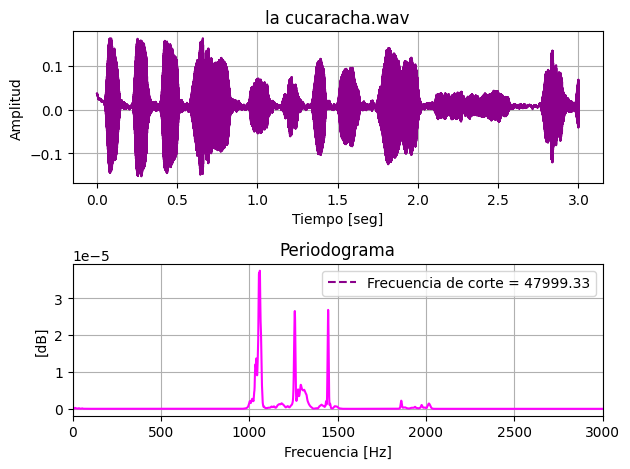

In [10]:
# ------------------------------------------- Audio 3 -> 'la cucaracha.wav' ------------------------------------------- #


# Utilizo método de Welch
promedios_audio_3 = 10 # defino la cantidad de bloques a promediar
nperseg_audio_3 = N_3 // promedios_audio_3
ff_3_welch, per_audio_3 = sp.welch (wav_data_3, nfft = 10*nperseg_audio_3, fs = fs_3, nperseg = nperseg_audio_3, window = 'hann')

energia_acum_3 = np.cumsum (per_audio_3)
energia_acum_3_norm = energia_acum_3 / energia_acum_3[-1]
corte_3 = energia_acum_3_norm[-1] * 0.995
indice_corte_3 = (int) (np.where (energia_acum_3_norm >= corte_3)[0][0])
frec_corte_3 = ff_3[indice_corte_2]


plt.figure (8)

plt.subplot (2, 1, 1)
plt.plot (tt_3, wav_data_3, color='darkmagenta')
plt.title ('la cucaracha.wav')
plt.xlabel ('Tiempo [seg]')
plt.ylabel ('Amplitud')
plt.grid (True)

plt.subplot (2, 1, 2)
plt.plot (ff_3_welch, per_audio_3, color='magenta')
plt.axvline (frec_corte_3, linestyle='--', color='darkmagenta', label=f'Frecuencia de corte = {frec_corte_3:.2f}')
plt.title ('Periodograma')
plt.xlabel ('Frecuencia [Hz]')
plt.ylabel ('[dB]')
plt.xlim (0, 3000)
plt.grid (True)
plt.legend ()

plt.tight_layout()
plt.show()

## Interpretación
- El espectro revela las componentes armónicas de la señal musical, típicas de melodías con instrumentación o voz.
- La frecuencia de corte permite delimitar el rango útil del contenido espectral, útil para compresión, análisis tonal o filtrado.
- El método de Welch ofrece una estimación estable, ideal para señales complejas como música.


# CONCLUSION 

Este trabajo presenta un análisis  del contenido espectral de señales biomédicas (ECG y PPG) y acústicas (audios .wav) mediante técnicas  de estimación de densidad espectral de potencia (PSD), con el objetivo de caracterizar su comportamiento frecuencial, comparar versiones limpias y ruidosas, y determinar frecuencias de corte relevantes. Se aplicaron tres métodos espectrales —Welch, Blackman-Tukey y periodograma ventaneado— cada uno con sus ventajas en resolución, suavidad y robustez frente al ruido. Las señales fisiológicas mostraron espectros concentrados en bajas frecuencias, mientras que las versiones contaminadas evidenciaron dispersión energética y elevación de la frecuencia de corte, reflejando la presencia de artefactos. En el caso de los audios, se logró identificar componentes tonales y armónicas mediante estimaciones precisas, destacando el impacto del método elegido sobre la forma del espectro. En conjunto, el trabajo demuestra una  integración entre teoría espectral, procesamiento digital y visualización técnica, permitiendo extraer conclusiones cuantitativas y cualitativas sobre la estructura interna de las señales analizadas.
